<a href="https://colab.research.google.com/github/surajgade17/EGFR-Bioactivity-Analysis/blob/main/EGFR_Bioactivity_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# EGFR Bioactivity Analysis
# Author: Suraj Gade | GitHub: surajgade17
# Data Source: ChEMBL Database
# Target: EGFR (CHEMBL203) - Cancer Drug Target
# ============================================

# Install required libraries
!pip install chembl_webresource_client rdkit

In [ ]:
# ============================================
# STEP 1: Import all required libraries
# ============================================

import pandas as pd          # Data manipulation
import numpy as np           # Numerical operations
import matplotlib.pyplot as plt  # Visualization
from chembl_webresource_client.new_client import new_client  # ChEMBL API
from rdkit import Chem                        # Molecule handling
from rdkit.Chem import Descriptors            # Molecular descriptors

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
# ============================================
# STEP 2: Fetch EGFR target from ChEMBL
# ============================================

# Search for EGFR in ChEMBL database
target = new_client.target
target_query = target.search('EGFR')
targets = pd.DataFrame.from_dict(target_query)

# Display top results to identify correct target
print("Top EGFR targets found in ChEMBL:")
print(targets[['target_chembl_id', 'pref_name', 'organism']].head(10))

Top EGFR targets found in ChEMBL:
  target_chembl_id                                          pref_name  \
0    CHEMBL4523747                                        EGFR/PPP1CA   
1    CHEMBL5465557                                          CCN2-EGFR   
2       CHEMBL3608                   Epidermal growth factor receptor   
3    CHEMBL6193842  Protein cereblon/Epidermal growth factor receptor   
4        CHEMBL203                   Epidermal growth factor receptor   
5    CHEMBL4523680  Protein cereblon/Epidermal growth factor receptor   
6    CHEMBL2363049                   Epidermal growth factor receptor   
7    CHEMBL3137284  MER intracellular domain/EGFR extracellular do...   
8    CHEMBL4523998  von Hippel-Lindau disease tumor suppressor/Epi...   
9    CHEMBL6193841  Protein cereblon/Epidermal growth factor receptor   

       organism  
0  Homo sapiens  
1  Homo sapiens  
2  Mus musculus  
3  Mus musculus  
4  Homo sapiens  
5  Homo sapiens  
6  Homo sapiens  
7  Homo sapiens  


In [ ]:
# ============================================
# STEP 3: Fetch bioactivity data for EGFR
# ============================================

# CHEMBL203 = Human EGFR (most studied cancer target)
# IC50 = concentration needed to inhibit 50% of target activity
# Lower IC50 = more potent compound

activity = new_client.activity
res = activity.filter(target_chembl_id='CHEMBL203', standard_type='IC50')
df = pd.DataFrame.from_dict(res)

print(f"✅ Total compounds fetched: {df.shape[0]}")
print(f"✅ Total columns: {df.shape[1]}")

✅ Total compounds fetched: 26600
✅ Total columns: 47


In [ ]:
# ============================================
# STEP 4: Select and clean useful columns
# ============================================

# Keep only relevant columns for analysis
# pchembl_value = -log10(IC50) — higher is better (more potent)
# standard_value = raw IC50 in nM
# canonical_smiles = molecular structure as text

df2 = df[['molecule_chembl_id',
          'canonical_smiles',
          'standard_value',
          'standard_units',
          'pchembl_value']].copy()

# Remove rows with missing SMILES or IC50
df2 = df2.dropna(subset=['canonical_smiles', 'standard_value'])

# Convert IC50 to numeric (remove any text values)
df2['standard_value'] = pd.to_numeric(df2['standard_value'], errors='coerce')
df2['pchembl_value'] = pd.to_numeric(df2['pchembl_value'], errors='coerce')

# Drop any remaining missing values
df2 = df2.dropna(subset=['standard_value'])

print(f"✅ Compounds after cleaning: {df2.shape[0]}")
print(df2.head())

✅ Compounds after cleaning: 25180
  molecule_chembl_id                                   canonical_smiles  \
0        CHEMBL68920  Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...   
1        CHEMBL68920  Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...   
2        CHEMBL68920  Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...   
3        CHEMBL69960  Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...   
4        CHEMBL69960  Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...   

   standard_value standard_units  pchembl_value  
0            41.0             nM           7.39  
1           300.0             nM           6.52  
2          7820.0             nM           5.11  
3           170.0             nM           6.77  
4            40.0             nM           7.40  


In [ ]:
# ============================================
# STEP 5: Label bioactivity classes
# ============================================

# IC50 <= 1000 nM = Active (potent inhibitor)
# IC50 >= 10000 nM = Inactive (weak/no inhibition)
# In between = Intermediate (removed to avoid ambiguity)

def label_bioactivity(value):
    if value <= 1000:
        return 'active'
    elif value >= 10000:
        return 'inactive'
    else:
        return 'intermediate'

df2['bioactivity_class'] = df2['standard_value'].apply(label_bioactivity)

# Remove intermediate compounds for clean binary analysis
df3 = df2[df2['bioactivity_class'] != 'intermediate'].copy()
df3 = df3.reset_index(drop=True)

print("✅ Bioactivity class distribution:")
print(df3['bioactivity_class'].value_counts())
print(f"\n✅ Final dataset size: {df3.shape[0]} compounds")

✅ Bioactivity class distribution:
bioactivity_class
active      18384
inactive     3644
Name: count, dtype: int64

✅ Final dataset size: 22028 compounds


In [ ]:
# ============================================
# STEP 6: Calculate Lipinski Descriptors
# ============================================

# Lipinski's Rule of Five — drug must satisfy:
# MW <= 500 (molecular weight)
# LogP <= 5 (lipophilicity)
# HBD <= 5 (hydrogen bond donors)
# HBA <= 10 (hydrogen bond acceptors)

def lipinski(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None, None, None, None
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)
    return mw, logp, hbd, hba

# Apply to all compounds
df3[['MW', 'LogP', 'HBD', 'HBA']] = df3['canonical_smiles'].apply(
    lambda x: pd.Series(lipinski(x))
)

# Remove any failed calculations
df3 = df3.dropna(subset=['MW', 'LogP', 'HBD', 'HBA'])

print(f"✅ Descriptors calculated for {df3.shape[0]} compounds")
print(df3[['MW', 'LogP', 'HBD', 'HBA']].describe().round(2))

✅ Descriptors calculated for 22028 compounds
             MW      LogP       HBD       HBA
count  22028.00  22028.00  22028.00  22028.00
mean     491.52      4.59      2.16      6.95
std      121.38      1.33      1.10      2.18
min      110.11     -2.38      0.00      1.00
25%      417.51      3.77      1.00      6.00
50%      487.50      4.51      2.00      7.00
75%      556.29      5.36      3.00      8.00
max     1425.80     13.03     11.00     19.00


In [ ]:
# ============================================
# STEP 7: Lipinski Pass/Fail Classification
# ============================================

# A drug-like molecule must pass ALL 4 rules
# This is a key filter in real drug discovery pipelines

def lipinski_pass(row):
    if (row['MW'] <= 500 and
        row['LogP'] <= 5 and
        row['HBD'] <= 5 and
        row['HBA'] <= 10):
        return 'Pass'
    else:
        return 'Fail'

df3['lipinski_pass'] = df3.apply(lipinski_pass, axis=1)

# Compare Lipinski pass/fail between active and inactive
print("✅ Overall Lipinski Pass/Fail:")
print(df3['lipinski_pass'].value_counts())

print("\n✅ Active compounds — Lipinski Pass/Fail:")
print(df3[df3['bioactivity_class']=='active']['lipinski_pass'].value_counts())

print("\n✅ Inactive compounds — Lipinski Pass/Fail:")
print(df3[df3['bioactivity_class']=='inactive']['lipinski_pass'].value_counts())

✅ Overall Lipinski Pass/Fail:
lipinski_pass
Fail    11912
Pass    10116
Name: count, dtype: int64

✅ Active compounds — Lipinski Pass/Fail:
lipinski_pass
Fail    10537
Pass     7847
Name: count, dtype: int64

✅ Inactive compounds — Lipinski Pass/Fail:
lipinski_pass
Pass    2269
Fail    1375
Name: count, dtype: int64


In [ ]:
# ============================================
# STEP 8: pChEMBL Value Analysis
# ============================================

# pchembl_value = -log10(IC50)
# Higher pchembl = more potent compound
# pchembl >= 6 is generally considered active
# pchembl >= 8 is considered highly potent

df3_pchembl = df3.dropna(subset=['pchembl_value'])

print(f"✅ Compounds with pChEMBL values: {df3_pchembl.shape[0]}")
print("\n✅ pChEMBL statistics by bioactivity class:")
print(df3_pchembl.groupby('bioactivity_class')['pchembl_value'].describe().round(2))

# Potency categories
def potency(p):
    if p >= 8:
        return 'Highly Potent'
    elif p >= 6:
        return 'Potent'
    else:
        return 'Weak'

df3_pchembl['potency_class'] = df3_pchembl['pchembl_value'].apply(potency)
print("\n✅ Potency distribution:")
print(df3_pchembl['potency_class'].value_counts())

✅ Compounds with pChEMBL values: 16401

✅ pChEMBL statistics by bioactivity class:
                     count  mean   std  min   25%   50%   75%   max
bioactivity_class                                                  
active             15176.0   7.6  0.98  6.0  6.81  7.55  8.30  11.0
inactive            1225.0   4.6  0.30  4.0  4.39  4.66  4.85   5.0

✅ Potency distribution:
potency_class
Potent           9831
Highly Potent    5345
Weak             1225
Name: count, dtype: int64


/tmp/ipykernel_2085/1067343123.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3_pchembl['potency_class'] = df3_pchembl['pchembl_value'].apply(potency)


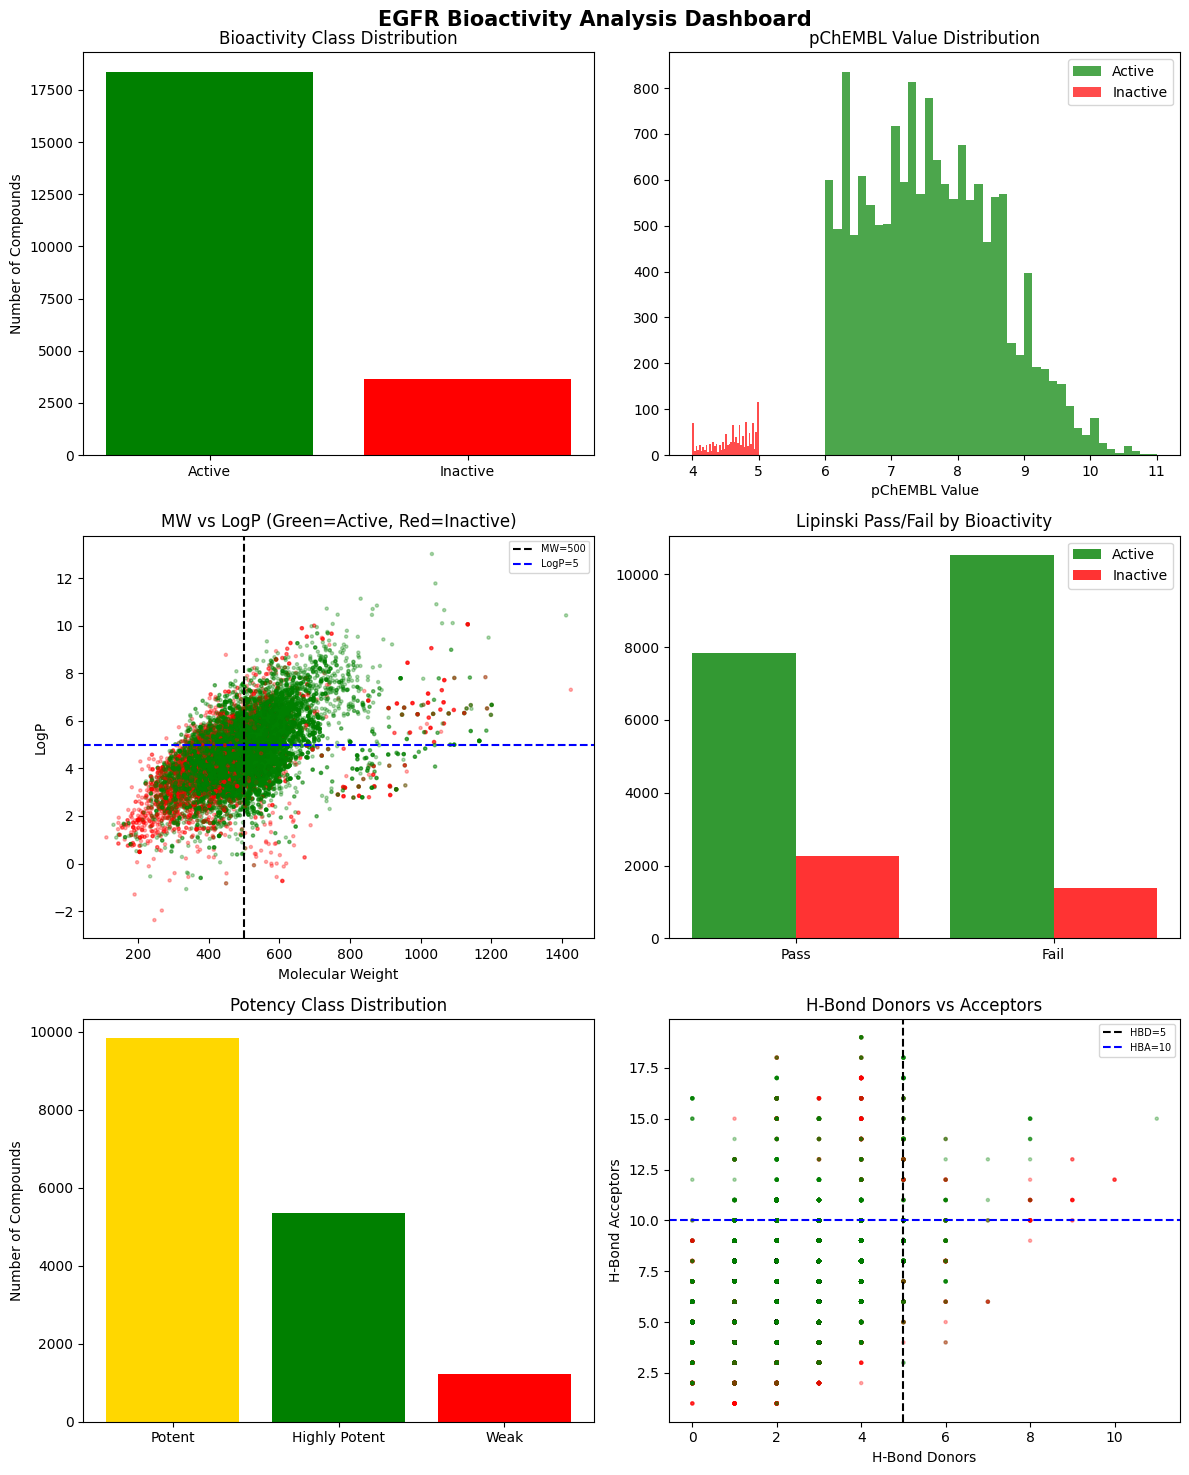

✅ Dashboard saved!


In [ ]:
# ============================================
# STEP 9: Complete Visualization Dashboard
# ============================================

fig, axes = plt.subplots(3, 2, figsize=(12, 15))

# Plot 1: Bioactivity class distribution
axes[0,0].bar(['Active', 'Inactive'], [18384, 3644],
              color=['green', 'red'])
axes[0,0].set_title('Bioactivity Class Distribution')
axes[0,0].set_ylabel('Number of Compounds')

# Plot 2: pChEMBL distribution
axes[0,1].hist(df3_pchembl[df3_pchembl['bioactivity_class']=='active']['pchembl_value'],
               bins=40, color='green', alpha=0.7, label='Active')
axes[0,1].hist(df3_pchembl[df3_pchembl['bioactivity_class']=='inactive']['pchembl_value'],
               bins=40, color='red', alpha=0.7, label='Inactive')
axes[0,1].set_title('pChEMBL Value Distribution')
axes[0,1].set_xlabel('pChEMBL Value')
axes[0,1].legend()

# Plot 3: MW vs LogP scatter colored by bioactivity
colors = df3['bioactivity_class'].map({'active':'green', 'inactive':'red'})
axes[1,0].scatter(df3['MW'], df3['LogP'],
                  c=colors, alpha=0.3, s=5)
axes[1,0].axvline(x=500, color='black', linestyle='--', label='MW=500')
axes[1,0].axhline(y=5, color='blue', linestyle='--', label='LogP=5')
axes[1,0].set_title('MW vs LogP (Green=Active, Red=Inactive)')
axes[1,0].set_xlabel('Molecular Weight')
axes[1,0].set_ylabel('LogP')
axes[1,0].legend(fontsize=7)

# Plot 4: Lipinski pass/fail by bioactivity
x = np.arange(2)
axes[1,1].bar(x - 0.2, [7847, 10537], 0.4,
              label='Active', color='green', alpha=0.8)
axes[1,1].bar(x + 0.2, [2269, 1375], 0.4,
              label='Inactive', color='red', alpha=0.8)
axes[1,1].set_title('Lipinski Pass/Fail by Bioactivity')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(['Pass', 'Fail'])
axes[1,1].legend()

# Plot 5: Potency class distribution
potency_counts = df3_pchembl['potency_class'].value_counts()
axes[2,0].bar(potency_counts.index, potency_counts.values,
              color=['gold', 'green', 'red'])
axes[2,0].set_title('Potency Class Distribution')
axes[2,0].set_ylabel('Number of Compounds')

# Plot 6: HBD vs HBA scatter
axes[2,1].scatter(df3['HBD'], df3['HBA'],
                  c=colors, alpha=0.3, s=5)
axes[2,1].axvline(x=5, color='black', linestyle='--', label='HBD=5')
axes[2,1].axhline(y=10, color='blue', linestyle='--', label='HBA=10')
axes[2,1].set_title('H-Bond Donors vs Acceptors')
axes[2,1].set_xlabel('H-Bond Donors')
axes[2,1].set_ylabel('H-Bond Acceptors')
axes[2,1].legend(fontsize=7)

plt.suptitle('EGFR Bioactivity Analysis Dashboard',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('egfr_dashboard.png', dpi=150)
plt.show()
print("✅ Dashboard saved!")

In [ ]:
# ============================================
# STEP 10: Save all files
# ============================================

# Save final dataset
df3.to_csv('EGFR_bioactivity_dataset.csv', index=False)
print("✅ Dataset saved!")

# Download all files
from google.colab import files
files.download('EGFR_bioactivity_dataset.csv')
files.download('egfr_dashboard.png')
files.download('EGFR_Bioactivity_Analysis.ipynb')
print("✅ All files downloaded!")

✅ Dataset saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FileNotFoundError: Cannot find file: EGFR_Bioactivity_Analysis.ipynb